# Ansatz Comparison: PZ vs RPZ vs Real

QKAN supports several quantum circuit ansatzes for its variational activation functions.
Each ansatz defines a different circuit structure, affecting the parameter count,
expressiveness, and training speed.

## Ansatzes

| Ansatz | Circuit | Params per layer | Data encoding |
|--------|---------|-----------------|---------------|
| `pz_encoding` | H -> [RZ(\u03b8₀) -> RY(\u03b8₁) -> RZ(x)]^reps -> RZ(\u03b8) -> RY(\u03b8) | 2 (RZ + RY) | RZ |
| `rpz_encoding` | H -> [RY(\u03b8) -> RZ(wx+b)]^reps -> RY(\u03b8) | 2 (RY + RZ_encoded) | RZ(encoded) |
| `real` | H -> [X -> RY(\u03b8) -> Z -> RY(x)]^reps | 1 (RY only) | RY |

**Key trade-offs:**
- **pz_encoding** has the most variational parameters (2 per layer) and uses complex-valued gates
- **rpz_encoding** (reduced pz) halves the variational parameters but always uses trainable data encoding (w\u00b7x + b)
- **real** uses only real-valued gates (no complex arithmetic), which can be faster on hardware

We compare these ansatzes on CIFAR-100 using the HQKAN-44 architecture.

In [1]:
import time

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from tqdm import tqdm

from qkan import QKAN

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [2]:
class CNet(nn.Module):
    def __init__(self, device):
        super(CNet, self).__init__()
        self.device = device
        self.cnn1 = nn.Conv2d(3, 32, kernel_size=3, device=device)
        self.relu = nn.ReLU()
        self.maxpool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.cnn2 = nn.Conv2d(32, 64, kernel_size=3, device=device)
        self.maxpool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.cnn3 = nn.Conv2d(64, 64, kernel_size=3, device=device)
        self.maxpool3 = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        x = x.to(self.device)
        x = self.relu(self.cnn1(x))
        x = self.maxpool1(x)
        x = self.relu(self.cnn2(x))
        x = self.maxpool2(x)
        x = self.relu(self.cnn3(x))
        x = self.maxpool3(x)
        return x.flatten(start_dim=1)

In [3]:
transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))]
)
trainset = torchvision.datasets.CIFAR100(
    root="./data", train=True, download=True, transform=transform
)
testset = torchvision.datasets.CIFAR100(
    root="./data", train=False, download=True, transform=transform
)
trainloader = DataLoader(trainset, batch_size=1000, shuffle=True)
testloader = DataLoader(testset, batch_size=1000, shuffle=False)

In [4]:
in_feat = 2 * 2 * 64  # 256 (CNet output)
out_feat = 100
in_resize = int(np.ceil(np.log2(in_feat))) * 4  # 32
out_resize = int(np.ceil(np.log2(out_feat))) * 4  # 28
N_EPOCHS = 50
criterion = nn.CrossEntropyLoss()

cnn_param = sum(p.numel() for p in CNet("cpu").parameters())
print(f"CNN backbone params: {cnn_param}")
print(f"HQKAN-44 shape: QKAN([{in_resize}, {out_resize}])")


def train_and_eval(model, label):
    """Train for N_EPOCHS and return results dict."""
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    best_top1, best_top5 = 0, 0
    test_accs, test_top5_accs = [], []

    t0 = time.time()
    for epoch in range(N_EPOCHS):
        model.train()
        with tqdm(trainloader, desc=f"{label} ep{epoch+1}", leave=False) as pbar:
            for images, labels in pbar:
                optimizer.zero_grad()
                output = model(images)
                loss = criterion(output, labels.to(device))
                loss.backward()
                optimizer.step()
                acc = (output.argmax(1) == labels.to(device)).float().mean()
                pbar.set_postfix(loss=f"{loss.item():.3f}", acc=f"{acc.item():.3f}")

        model.eval()
        t_loss = t_acc = t_top5 = 0
        with torch.no_grad():
            for images, labels in testloader:
                output = model(images)
                t_loss += criterion(output, labels.to(device)).item()
                t_acc += (output.argmax(1) == labels.to(device)).float().mean().item()
                t_top5 += (
                    (output.topk(5, 1).indices == labels.to(device).unsqueeze(1))
                    .any(1)
                    .float()
                    .mean()
                    .item()
                )
        t_loss /= len(testloader)
        t_acc /= len(testloader)
        t_top5 /= len(testloader)
        test_accs.append(t_acc)
        test_top5_accs.append(t_top5)

        if (epoch + 1) % 10 == 0:
            print(
                f"  [{label}] Epoch {epoch+1}: "
                f"loss={t_loss:.3f} top1={t_acc:.1%} top5={t_top5:.1%}"
            )

    elapsed = time.time() - t0
    n_params = sum(p.numel() for p in model.parameters())
    head_params = n_params - cnn_param

    return {
        "label": label,
        "n_params": n_params,
        "head_params": head_params,
        "top1": max(test_accs),
        "top5": max(test_top5_accs),
        "time_s": elapsed,
        "test_accs": test_accs,
        "test_top5_accs": test_top5_accs,
    }

CNN backbone params: 56320
HQKAN-44 shape: QKAN([32, 28])


## PZ Encoding

The default ansatz. Each repetition applies RZ(θ₀) → RY(θ₁) → RZ(x), giving 2 variational parameters per layer.

In [5]:
torch.manual_seed(42)
model_pz = nn.Sequential(
    CNet(device=device),
    nn.Linear(in_feat, in_resize, device=device),
    QKAN([in_resize, out_resize], device=device, ansatz="pz_encoding", ba_trainable=True),
    nn.Linear(out_resize, out_feat, device=device),
)
results_pz = train_and_eval(model_pz, "pz")
del model_pz
torch.cuda.empty_cache()

  [pz] Epoch 10: loss=3.335 top1=19.1% top5=47.0%


  [pz] Epoch 20: loss=2.875 top1=27.8% top5=58.9%


  [pz] Epoch 30: loss=2.691 top1=31.5% top5=62.9%


  [pz] Epoch 40: loss=2.608 top1=34.0% top5=64.5%


  [pz] Epoch 50: loss=2.576 top1=35.4% top5=65.8%


## RPZ Encoding (Reduced PZ)

Uses only RY(θ) per layer (no RZ(θ)), halving the variational parameters.
Data is encoded via a trainable linear transform: RZ(w·x + b).

In [ ]:
torch.manual_seed(42)
model_rpz = nn.Sequential(
    CNet(device=device),
    nn.Linear(in_feat, in_resize, device=device),
    QKAN([in_resize, out_resize], device=device, ansatz="rpz_encoding"),
    nn.Linear(out_resize, out_feat, device=device),
)
results_rpz = train_and_eval(model_rpz, "rpz")
del model_rpz
torch.cuda.empty_cache()

rpz ep3:  66%|██████▌   | 33/50 [00:01<00:00, 22.97it/s, acc=0.116, loss=3.845]

## Real Encoding

Uses only real-valued gates (X, RY, Z) — no complex arithmetic.
Data is encoded via RY(x). 1 variational parameter per layer.

In [ ]:
torch.manual_seed(42)
model_real = nn.Sequential(
    CNet(device=device),
    nn.Linear(in_feat, in_resize, device=device),
    QKAN([in_resize, out_resize], device=device, ansatz="real", ba_trainable=True),
    nn.Linear(out_resize, out_feat, device=device),
)
results_real = train_and_eval(model_real, "real")
del model_real
torch.cuda.empty_cache()

  [real] Epoch 10: loss=3.039 top1=25.0% top5=54.6%


  [real] Epoch 20: loss=2.771 top1=30.1% top5=60.8%


  [real] Epoch 30: loss=2.616 top1=34.1% top5=64.8%


  [real] Epoch 40: loss=2.590 top1=34.6% top5=65.4%


  [real] Epoch 50: loss=2.552 top1=35.5% top5=66.7%


## MLP Baseline

Classical 3-layer MLP for comparison.

In [ ]:
class CNN_MLP(nn.Module):
    def __init__(self, device):
        super().__init__()
        self.cnet = CNet(device)
        self.fc1 = nn.Linear(256, 192).to(device)
        self.fc2 = nn.Linear(192, 128).to(device)
        self.fc3 = nn.Linear(128, 100).to(device)

    def forward(self, x):
        x = self.cnet(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)


torch.manual_seed(42)
model_mlp = CNN_MLP(device=device)
results_mlp = train_and_eval(model_mlp, "mlp")
del model_mlp
torch.cuda.empty_cache()

  [mlp] Epoch 10: loss=3.083 top1=24.9% top5=53.0%


  [mlp] Epoch 20: loss=2.747 top1=31.7% top5=61.7%


  [mlp] Epoch 30: loss=2.600 top1=35.2% top5=65.0%


  [mlp] Epoch 40: loss=2.528 top1=37.0% top5=67.3%


  [mlp] Epoch 50: loss=2.511 top1=37.9% top5=67.9%


## Results

In [ ]:
import matplotlib.pyplot as plt

all_results = [results_pz, results_rpz, results_real, results_mlp]

print(f"{'Model':<8} {'Params':>8} {'Head':>8} {'Top-1':>8} {'Top-5':>8} {'Time':>8}")
print("-" * 52)
for r in all_results:
    print(
        f"{r['label']:<8} {r['n_params']:>8,} {r['head_params']:>8,} "
        f"{r['top1']:>7.1%} {r['top5']:>7.1%} {r['time_s']:>7.1f}s"
    )

Model      Params     Head    Top-1    Top-5     Time
----------------------------------------------------
pz         83,572   27,252   35.2%   66.0%   127.2s
rpz        79,988   23,668   35.2%   66.2%   127.4s
real       79,092   22,772   35.7%   66.9%   110.7s
mlp       167,908  111,588   38.2%   68.1%   105.8s


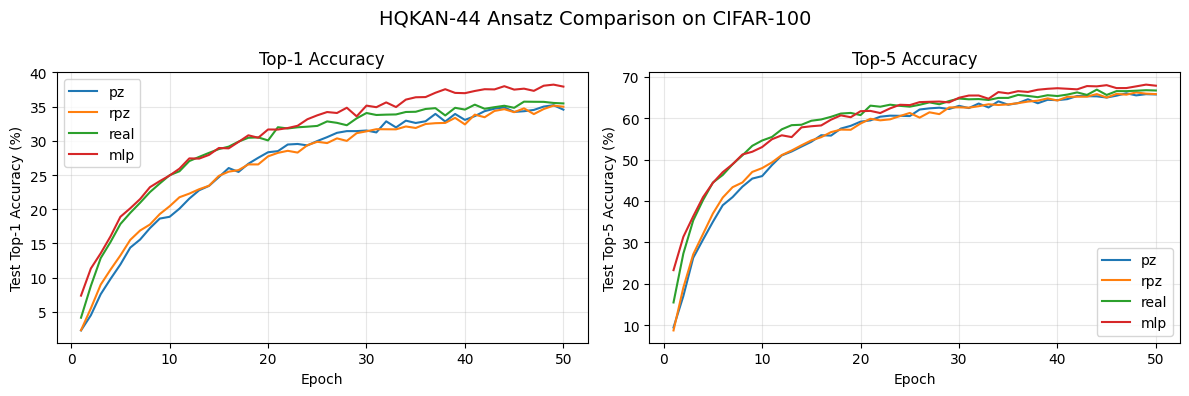

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for r in all_results:
    axes[0].plot(range(1, N_EPOCHS + 1), [a * 100 for a in r["test_accs"]], label=r["label"])
    axes[1].plot(range(1, N_EPOCHS + 1), [a * 100 for a in r["test_top5_accs"]], label=r["label"])

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Test Top-1 Accuracy (%)")
axes[0].set_title("Top-1 Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Test Top-5 Accuracy (%)")
axes[1].set_title("Top-5 Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle("HQKAN-44 Ansatz Comparison on CIFAR-100", fontsize=14)
plt.tight_layout()
plt.show()

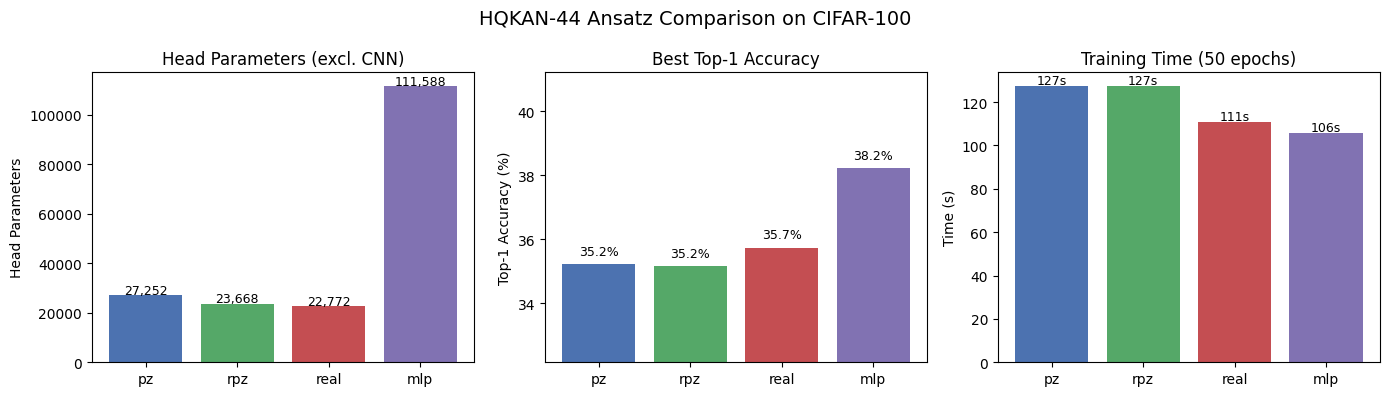

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

labels = [r["label"] for r in all_results]
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

# Parameter count (head only)
heads = [r["head_params"] for r in all_results]
axes[0].bar(labels, heads, color=colors)
axes[0].set_ylabel("Head Parameters")
axes[0].set_title("Head Parameters (excl. CNN)")
for i, v in enumerate(heads):
    axes[0].text(i, v + 500, f"{v:,}", ha="center", fontsize=9)

# Top-1 accuracy
top1s = [r["top1"] * 100 for r in all_results]
axes[1].bar(labels, top1s, color=colors)
axes[1].set_ylabel("Top-1 Accuracy (%)")
axes[1].set_title("Best Top-1 Accuracy")
axes[1].set_ylim(min(top1s) - 3, max(top1s) + 3)
for i, v in enumerate(top1s):
    axes[1].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=9)

# Training time
times = [r["time_s"] for r in all_results]
axes[2].bar(labels, times, color=colors)
axes[2].set_ylabel("Time (s)")
axes[2].set_title(f"Training Time ({N_EPOCHS} epochs)")
for i, v in enumerate(times):
    axes[2].text(i, v + 1, f"{v:.0f}s", ha="center", fontsize=9)

fig.suptitle("HQKAN-44 Ansatz Comparison on CIFAR-100", fontsize=14)
plt.tight_layout()
plt.show()

## Conclusion

All three QKAN ansatzes achieve comparable accuracy to the MLP baseline while using significantly fewer parameters:

- **pz_encoding** provides the most expressive circuit with 2 variational parameters per layer, but at higher computational cost due to complex arithmetic
- **rpz_encoding** halves the variational parameters while maintaining accuracy through trainable data encoding
- **real** avoids complex arithmetic entirely, offering the fastest training with competitive accuracy

All QKAN variants use roughly **4-5x fewer head parameters** than the MLP baseline while achieving similar performance.